In [1]:
#env-scgpt
import os
import sys
from pathlib import Path
import numpy as np
from scipy.stats import mode
import scanpy as sc
import warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import sys
import scgpt as scg

# extra dependency for similarity search
try:
    import faiss

    faiss_imported = True
except ImportError:
    faiss_imported = False
    print(
        "faiss not installed! We highly recommend installing it for fast similarity search."
    )
    print("To install it, see https://github.com/facebookresearch/faiss/wiki/Installing-Faiss")

warnings.filterwarnings("ignore", category=ResourceWarning)

/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/faiss/loader.py:28: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(numpy.__version__) >= "1.19":
/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/setuptools/_distutils/version.py:337: DeprecationWarning: distutils Version classes are deprecated. Use packaging.vers

In [2]:
model_dir = Path("/data2/lanxiang/embryo_benchmark/scGPT/scGPT_human")
adata = sc.read_h5ad('/data2/lanxiang/embryo_benchmark/25.1.13_update/human_clustering_20250724_v3.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 33794 × 60428
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage'
    var: 'features', 'n_cells', 'highly_variable'
    uns: 'dendrogram_reanno', 'harmo.anno_colors', 'hvg', 'leiden', 'leiden_3_colors', 'lineage_colors', 'log1p', 'neighbors', 'orig.ident_colors', 'orig_sub_anno_colors', 'pca', 'rank_genes_groups', 'reanno_colors', 'scANVI_res_0.5_colors', 'stage_colors', 'umap', 'unicorns_colors'
    obsm: 'X_pca', 'X_scANVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [4]:
Weatherbee = sc.read_h5ad('/data2/lanxiang/embryo_benchmark/9.27labeltransfer_data/corrected_processed_Weatherbee.h5ad')

In [5]:
Weatherbee

AnnData object with n_obs × n_vars = 5901 × 31531
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'stage', 'species', 'embryo', 'platform', 'doublet', 'doublet_score'
    var: 'features', 'n_cells'

In [6]:
Weatherbee.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,sample_type,scmap_nakamura,scmapCELL_Yang,scmap_ma,scmap_Tyser,scmapCELL_Mole,cell_assignment,course_cell_assignment,stage,species,embryo,platform,doublet,doublet_score
AAACAGCCAATATACC-1_1,Weatherbee,7994.0,3257,4.953715,double_structure_day8,Post-paTE,unassigned,L-AM2,Amnion,Hypoblast,AM-3,AME,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,1.516193e-05
AAACAGCCACTAAGCC-1_1,Weatherbee,8411.0,3593,4.541672,double_structure_day8,Post-paTE,unassigned,L-AM2,Amnion,Cytotrophoblasts,AM-3,AME,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,3.050282e-04
AAACATGCAGTATGTT-1_1,Weatherbee,7937.0,3497,3.187602,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,unassigned,Hypoblast,EXMC,EXMC,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,9.171038e-07
AAACCAACAATAACCT-1_1,Weatherbee,10750.0,4132,2.483721,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,YS Mesoderm,Hypoblast,EXMC,EXMC,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,2.359281e-08
AAACCGAAGGCTAGAA-1_1,Weatherbee,10730.0,4098,3.122088,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,YS Mesoderm,Hypoblast,EXMC,EXMC,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,2.735409e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGAGTCATCCGTAA-1,Weatherbee,29746.0,6569,10.925839,double_structure_day4,PostL-EPI,unassigned,postL-EPI,Epiblast,Epiblast,L-EPI,L-EPI,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,3.586937e-04
TTTGGTAAGTTACTTC-1,Weatherbee,44527.0,8383,8.978822,NA,NA,NA,NA,NA,NA,NA,NA,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,4.157939e+00
TTTGTCTAGCATGAAG-1,Weatherbee,9015.0,3987,3.982252,double_structure_day4,PostL-EPI,unassigned,L-AM1,Epiblast,unassigned,AM-1,AME,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,4.369414e-01
TTTGTGAAGTTAACCA-1,Weatherbee,24582.0,6431,4.653812,double_structure_day4,EXMC,extraembryonic mesenchyme,L-Gast2,unassigned,unassigned,MESO-2,Meso,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,6.811725e-01


In [7]:
adata_hvg = adata[:, adata.var.highly_variable].copy()

In [8]:
adata_hvg

AnnData object with n_obs × n_vars = 33794 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage'
    var: 'features', 'n_cells', 'highly_variable'
    uns: 'dendrogram_reanno', 'harmo.anno_colors', 'hvg', 'leiden', 'leiden_3_colors', 'lineage_colors', 'log1p', 'neighbors', 'orig.ident_colors', 'orig_sub_anno_colors', 'pca', 'rank_genes_groups', 'reanno_colors', 'scANVI_res_0.5_colors', 'stage_colors', 'umap', 'unicorns_colors'
    obsm: 'X_pca', 'X_scANVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [9]:
print(adata_hvg.X)

  (0, 0)	0.5896574616062754
  (0, 1)	0.0855016865466988
  (0, 4)	0.0855016865466988
  (0, 6)	0.5896574616062754
  (0, 8)	0.3053158743576146
  (0, 11)	0.0855016865466988
  (0, 12)	0.16426518125366685
  (0, 26)	0.0855016865466988
  (0, 32)	0.16426518125366685
  (0, 37)	1.17297271685056
  (0, 39)	0.0855016865466988
  (0, 45)	0.0855016865466988
  (0, 46)	0.8871561621240867
  (0, 52)	0.0855016865466988
  (0, 56)	0.3053158743576146
  (0, 60)	0.0855016865466988
  (0, 61)	0.6379695013722114
  (0, 62)	0.0855016865466988
  (0, 72)	0.0855016865466988
  (0, 74)	0.6379695013722114
  (0, 75)	0.9581008480317472
  (0, 76)	0.16426518125366685
  (0, 78)	0.0855016865466988
  (0, 79)	0.16426518125366685
  (0, 81)	0.0855016865466988
  :	:
  (33793, 1847)	2.162325013493941
  (33793, 1860)	1.8127946291744954
  (33793, 1861)	2.0027541459605565
  (33793, 1877)	1.5780836266958929
  (33793, 1880)	0.8250027048891198
  (33793, 1883)	1.5780836266958929
  (33793, 1884)	1.270820060666488
  (33793, 1885)	1.27082006066

In [10]:
print(Weatherbee.X)

  (0, 25)	1.0
  (0, 36)	1.0
  (0, 40)	1.0
  (0, 53)	1.0
  (0, 54)	1.0
  (0, 75)	1.0
  (0, 77)	2.0
  (0, 128)	1.0
  (0, 145)	8.0
  (0, 164)	1.0
  (0, 168)	1.0
  (0, 175)	1.0
  (0, 181)	1.0
  (0, 184)	2.0
  (0, 188)	9.0
  (0, 191)	1.0
  (0, 211)	1.0
  (0, 215)	1.0
  (0, 216)	1.0
  (0, 223)	1.0
  (0, 234)	1.0
  (0, 249)	1.0
  (0, 263)	1.0
  (0, 287)	1.0
  (0, 320)	1.0
  :	:
  (5900, 31431)	1.0
  (5900, 31438)	2.0
  (5900, 31444)	7.0
  (5900, 31446)	1.0
  (5900, 31447)	37.0
  (5900, 31454)	2.0
  (5900, 31456)	2.0
  (5900, 31457)	1.0
  (5900, 31459)	1.0
  (5900, 31464)	5.0
  (5900, 31469)	2.0
  (5900, 31472)	1.0
  (5900, 31505)	91.0
  (5900, 31506)	52.0
  (5900, 31507)	461.0
  (5900, 31508)	429.0
  (5900, 31509)	18.0
  (5900, 31510)	348.0
  (5900, 31511)	629.0
  (5900, 31512)	46.0
  (5900, 31513)	7.0
  (5900, 31514)	84.0
  (5900, 31515)	37.0
  (5900, 31516)	5.0
  (5900, 31517)	230.0


In [11]:
sc.settings.seed = 42
Weatherbee.layers["counts"] =Weatherbee.X.copy()
sc.pp.normalize_total(Weatherbee, target_sum=1e4)
sc.pp.log1p(Weatherbee)
Weatherbee.layers["logcounts"] = Weatherbee.X.copy()
sc.pp.highly_variable_genes(Weatherbee, n_top_genes=2000, flavor="cell_ranger", batch_key="orig.ident")
sc.tl.pca(Weatherbee, n_comps=30, use_highly_variable=True)

In [12]:
Weatherbee_hvg = Weatherbee[:, Weatherbee.var.highly_variable].copy()

In [13]:
Weatherbee_hvg

AnnData object with n_obs × n_vars = 5901 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'stage', 'species', 'embryo', 'platform', 'doublet', 'doublet_score'
    var: 'features', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

# final_anno

In [14]:
gene_col = "features"
cell_type_key = "reanno"

In [15]:
original_adata_hvg = adata_hvg.copy()
original_Weatherbee_hvg=Weatherbee_hvg.copy()

In [16]:
ref_embed_adata = scg.tasks.embed_data(
    adata_hvg,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)


scGPT - INFO - match 1844/2000 genes in vocabulary of size 60697.


/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|██████████| 529/529 [02:44<00:00,  3.21it/s]


In [17]:
test_embed_adata = scg.tasks.embed_data(
    Weatherbee_hvg,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)

scGPT - INFO - match 1715/2000 genes in vocabulary of size 60697.


/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|██████████| 93/93 [00:38<00:00,  2.39it/s]


In [18]:
ref_embed_adata

AnnData object with n_obs × n_vars = 33794 × 1844
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage'
    var: 'features', 'n_cells', 'highly_variable', 'id_in_vocab'
    uns: 'dendrogram_reanno', 'harmo.anno_colors', 'hvg', 'leiden', 'leiden_3_colors', 'lineage_colors', 'log1p', 'neighbors', 'orig.ident_colors', 'orig_sub_anno_colors', 'pca', 'rank_genes_groups', 'reanno_colors', 'scANVI_res_0.5_colors', 'stage_colors', 'umap', 'unicorns_colors'
    obsm: 'X_pca', 'X_scANVI', 'X_umap', 'X_scGPT'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [19]:
test_embed_adata

AnnData object with n_obs × n_vars = 5901 × 1715
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'stage', 'species', 'embryo', 'platform', 'doublet', 'doublet_score'
    var: 'features', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'id_in_vocab'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca', 'X_scGPT'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [20]:
# concatenate the two datasets
adata_concat = test_embed_adata.concatenate(ref_embed_adata, batch_key="dataset")
# mark the reference vs. query dataset
adata_concat.obs["is_ref"] = ["Query"] * len(test_embed_adata) + ["Reference"] * len(
    ref_embed_adata
)
adata_concat.obs["is_ref"] = adata_concat.obs["is_ref"].astype("category")
# mask the query dataset cell types
adata_concat.obs[cell_type_key] = adata_concat.obs[cell_type_key].astype('category')
adata_concat.obs[cell_type_key] = adata_concat.obs[cell_type_key].cat.add_categories(["To be predicted"])
adata_concat.obs[cell_type_key][: len(test_embed_adata)] = "To be predicted"

/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


In [21]:
adata_concat

AnnData object with n_obs × n_vars = 39695 × 841
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'stage', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'sample', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage', 'dataset', 'is_ref'
    var: 'features', 'highly_variable', 'id_in_vocab', 'n_cells-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'highly_variable_nbatches-0', 'highly_variable_intersection-0', 'n_cells-1'
    obsm: 'X_pca', 'X_scGPT'
    layers: 'counts', 'logcounts'

In [22]:
adata_concat.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,sample_type,scmap_nakamura,scmapCELL_Yang,scmap_ma,scmap_Tyser,scmapCELL_Mole,...,orig_sub_anno,harmo.anno,scANVI_res_0.5,leiden_3,reanno,combined_annotation,unicorns,lineage,dataset,is_ref
AAACAGCCAATATACC-1_1-0,Weatherbee,7994.0,3257,4.953715,double_structure_day8,Post-paTE,unassigned,L-AM2,Amnion,Hypoblast,...,NaN,NaN,NaN,NaN,To be predicted,NaN,NaN,NaN,0,Query
AAACAGCCACTAAGCC-1_1-0,Weatherbee,8411.0,3593,4.541672,double_structure_day8,Post-paTE,unassigned,L-AM2,Amnion,Cytotrophoblasts,...,NaN,NaN,NaN,NaN,To be predicted,NaN,NaN,NaN,0,Query
AAACATGCAGTATGTT-1_1-0,Weatherbee,7937.0,3497,3.187602,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,unassigned,Hypoblast,...,NaN,NaN,NaN,NaN,To be predicted,NaN,NaN,NaN,0,Query
AAACCAACAATAACCT-1_1-0,Weatherbee,10750.0,4132,2.483721,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,YS Mesoderm,Hypoblast,...,NaN,NaN,NaN,NaN,To be predicted,NaN,NaN,NaN,0,Query
AAACCGAAGGCTAGAA-1_1-0,Weatherbee,10730.0,4098,3.122088,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,YS Mesoderm,Hypoblast,...,NaN,NaN,NaN,NaN,To be predicted,NaN,NaN,NaN,0,Query
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGAACGCATTACGGT-1-1,Yuan_2025,3571.0,2345,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,11,0.4.1,Spinal.cord,Spinal.cord_CS9,non-unicorn,neural_ecto,1,Reference
TTGCATTCAACCGCCA-1-1,Yuan_2025,8130.0,3961,0.012300,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,7,0.5.0,Somite,Somite_CS9,non-unicorn,meso_Exe.meso,1,Reference
TTGTTGTAGTCACAGG-1-1,Yuan_2025,6185.0,3324,0.048504,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,9,0.3.0,Lateral.plate.mesoderm_2,Lateral.plate.mesoderm_2_CS9,non-unicorn,meso_Exe.meso,1,Reference
TTTACGTAGTTACGGG-1-1,Yuan_2025,5110.0,2964,0.078278,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,10,0.4.0,Neural.ectoderm.forebrain,Neural.ectoderm.forebrain_CS9,non-unicorn,neural_ecto,1,Reference


/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


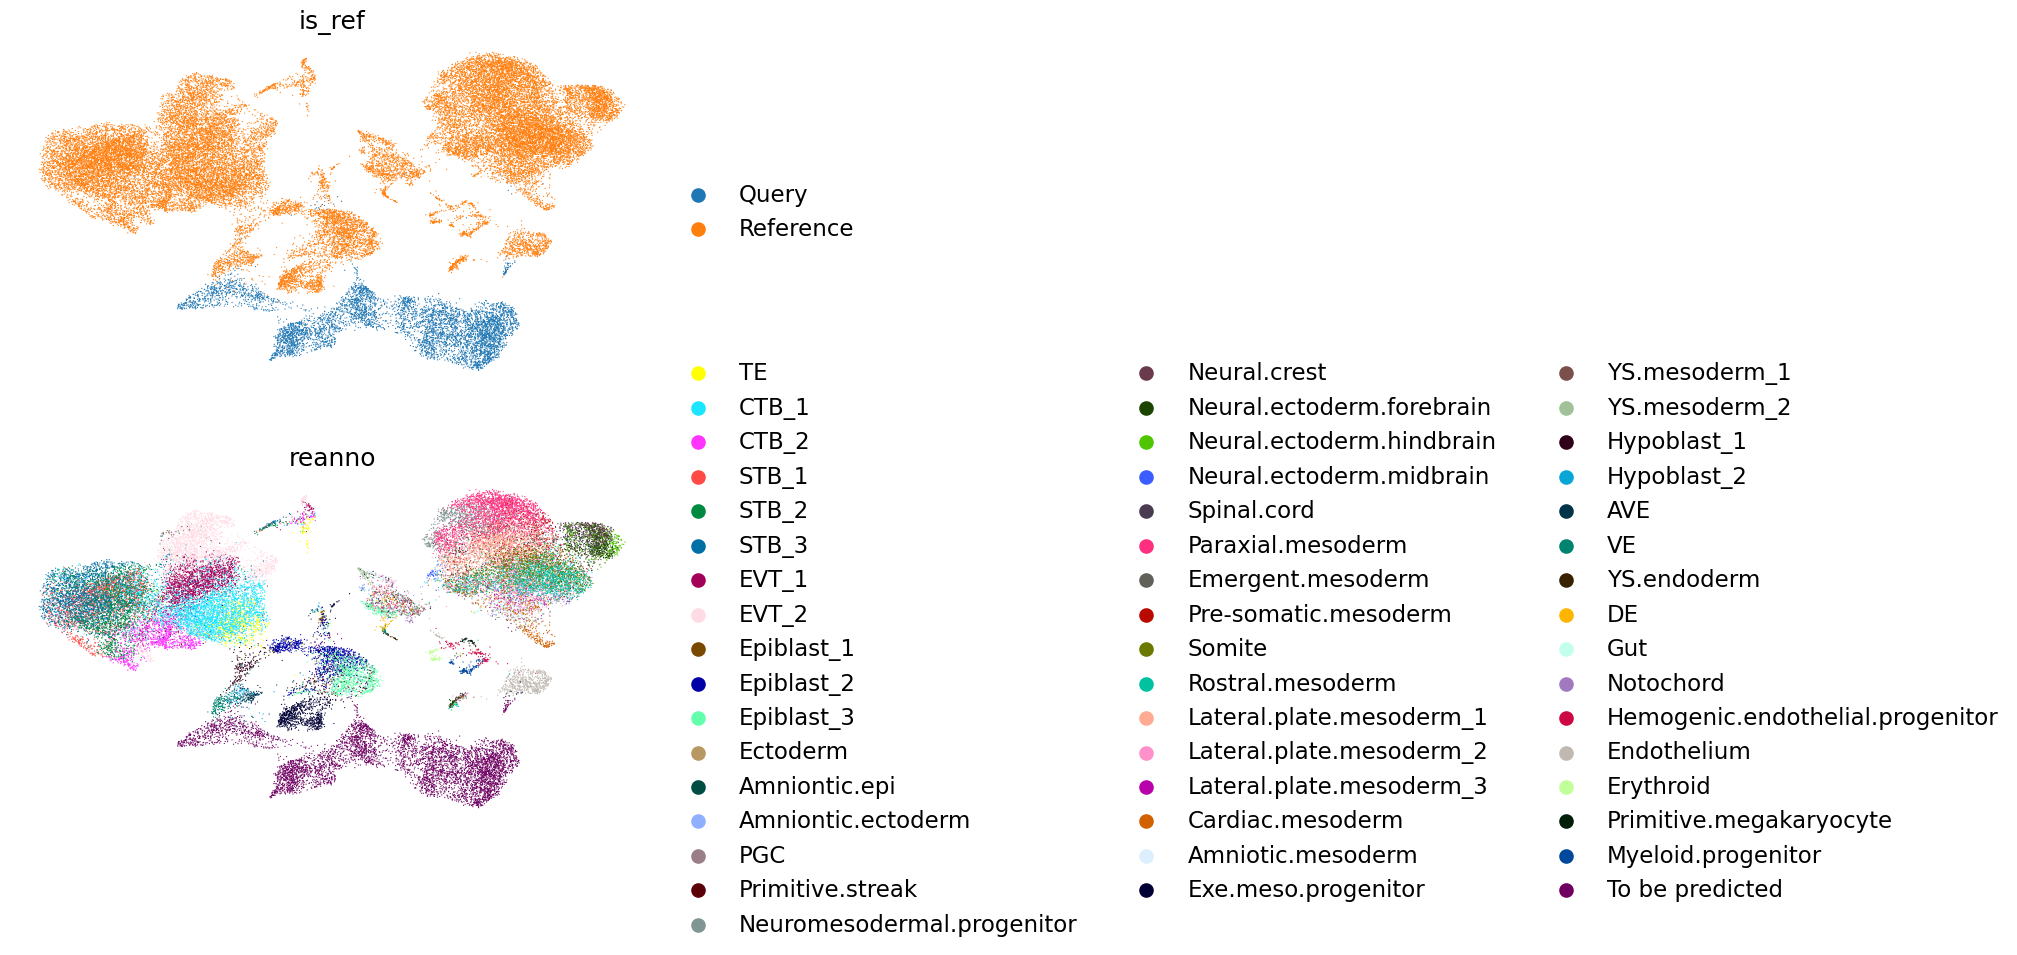

In [23]:
sc.pp.neighbors(adata_concat, use_rep="X_scGPT")
sc.tl.umap(adata_concat)
sc.pl.umap(adata_concat, color=["is_ref", cell_type_key], wspace=0.4, frameon=False, ncols=1)

In [24]:
ref_cell_embeddings = ref_embed_adata.obsm["X_scGPT"]
test_emebd = test_embed_adata.obsm["X_scGPT"]

k = 10  # number of neighbors

index = faiss.IndexFlatL2(ref_cell_embeddings.shape[1])
index.add(ref_cell_embeddings)

# Query dataset, k - number of closest elements (returns 2 numpy arrays)
distances, labels = index.search(test_emebd, k)

idx_list=[i for i in range(test_emebd.shape[0])]
preds = []
sim_list = distances
for k in idx_list:
    if faiss_imported:
        idx = labels[k]
    else:
        idx, sim = get_similar_vectors(test_emebd[k][np.newaxis, ...], ref_cell_embeddings, k)
    pred = ref_embed_adata.obs[cell_type_key][idx].value_counts()
    preds.append(pred.index[0])

In [25]:
preds

['Rostral.mesoderm',
 'Somite',
 'Rostral.mesoderm',
 'Exe.meso.progenitor',
 'Amniotic.mesoderm',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'Amniontic.ectoderm',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'Rostral.mesoderm',
 'Amniontic.epi',
 'Rostral.mesoderm',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'Rostral.mesoderm',
 'VE',
 'Exe.meso.progenitor',
 'Rostral.mesoderm',
 'Exe.meso.progenitor',
 'Rostral.mesoderm',
 'Amniontic.ectoderm',
 'Rostral.mesoderm',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'Rostral.mesoderm',
 'Amniontic.ectoderm',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'VE',
 'Exe.meso.progenitor',
 'Amniotic.mesoderm',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'Amniontic.ectoderm',
 'Rostral.mesoderm',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor',
 'Rostral.mesoderm',
 'Somite',
 'Rostral.mesoderm',
 'Exe.

In [26]:
len(preds)

5901

In [27]:
adata_concat

AnnData object with n_obs × n_vars = 39695 × 841
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'stage', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'sample', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage', 'dataset', 'is_ref'
    var: 'features', 'highly_variable', 'id_in_vocab', 'n_cells-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'highly_variable_nbatches-0', 'highly_variable_intersection-0', 'n_cells-1'
    uns: 'neighbors', 'umap', 'is_ref_colors', 'reanno_colors'
    obsm: 'X_pca', 'X_scGPT', 'X_umap'
    layers: 'counts', 'logcounts'
    obsp: 'distances', 'connectivities'

In [28]:
adata_concat.obs["orig.ident"].value_counts()

orig.ident
zeng          13774
Ai             8675
Weatherbee     5901
mole           5229
zhou           4244
tyser          1189
xiang           521
Yuan_2025       162
Name: count, dtype: int64

In [29]:
Weatherbee.obs["scgpt_final_anno_pre"] = preds

In [30]:
Weatherbee.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,sample_type,scmap_nakamura,scmapCELL_Yang,scmap_ma,scmap_Tyser,scmapCELL_Mole,cell_assignment,course_cell_assignment,stage,species,embryo,platform,doublet,doublet_score,scgpt_final_anno_pre
AAACAGCCAATATACC-1_1,Weatherbee,7994.0,3257,4.953715,double_structure_day8,Post-paTE,unassigned,L-AM2,Amnion,Hypoblast,AM-3,AME,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,1.516193e-05,Rostral.mesoderm
AAACAGCCACTAAGCC-1_1,Weatherbee,8411.0,3593,4.541672,double_structure_day8,Post-paTE,unassigned,L-AM2,Amnion,Cytotrophoblasts,AM-3,AME,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,3.050282e-04,Somite
AAACATGCAGTATGTT-1_1,Weatherbee,7937.0,3497,3.187602,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,unassigned,Hypoblast,EXMC,EXMC,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,9.171038e-07,Rostral.mesoderm
AAACCAACAATAACCT-1_1,Weatherbee,10750.0,4132,2.483721,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,YS Mesoderm,Hypoblast,EXMC,EXMC,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,2.359281e-08,Exe.meso.progenitor
AAACCGAAGGCTAGAA-1_1,Weatherbee,10730.0,4098,3.122088,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,YS Mesoderm,Hypoblast,EXMC,EXMC,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,2.735409e-09,Amniotic.mesoderm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGAGTCATCCGTAA-1,Weatherbee,29746.0,6569,10.925839,double_structure_day4,PostL-EPI,unassigned,postL-EPI,Epiblast,Epiblast,L-EPI,L-EPI,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,3.586937e-04,Epiblast_3
TTTGGTAAGTTACTTC-1,Weatherbee,44527.0,8383,8.978822,NA,NA,NA,NA,NA,NA,NA,NA,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,4.157939e+00,Neural.ectoderm.forebrain
TTTGTCTAGCATGAAG-1,Weatherbee,9015.0,3987,3.982252,double_structure_day4,PostL-EPI,unassigned,L-AM1,Epiblast,unassigned,AM-1,AME,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,4.369414e-01,Epiblast_3
TTTGTGAAGTTAACCA-1,Weatherbee,24582.0,6431,4.653812,double_structure_day4,EXMC,extraembryonic mesenchyme,L-Gast2,unassigned,unassigned,MESO-2,Meso,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,6.811725e-01,Exe.meso.progenitor


# final_lineage

In [31]:
gene_col = "features"
cell_type_key = "lineage"

In [32]:
adata_hvg = original_adata_hvg.copy()
Weatherbee_hvg = original_Weatherbee_hvg.copy()

In [33]:
ref_embed_adata = scg.tasks.embed_data(
    adata_hvg,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)


scGPT - INFO - match 1844/2000 genes in vocabulary of size 60697.


/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|██████████| 529/529 [02:27<00:00,  3.60it/s]


In [34]:
test_embed_adata = scg.tasks.embed_data(
    Weatherbee_hvg,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)

scGPT - INFO - match 1715/2000 genes in vocabulary of size 60697.


/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|██████████| 93/93 [00:48<00:00,  1.91it/s]


In [35]:
# concatenate the two datasets
adata_concat = test_embed_adata.concatenate(ref_embed_adata, batch_key="dataset")
# mark the reference vs. query dataset
adata_concat.obs["is_ref"] = ["Query"] * len(test_embed_adata) + ["Reference"] * len(
    ref_embed_adata
)
adata_concat.obs["is_ref"] = adata_concat.obs["is_ref"].astype("category")
# mask the query dataset cell types
adata_concat.obs[cell_type_key] = adata_concat.obs[cell_type_key].astype('category')
adata_concat.obs[cell_type_key] = adata_concat.obs[cell_type_key].cat.add_categories(["To be predicted"])
adata_concat.obs[cell_type_key][: len(test_embed_adata)] = "To be predicted"

/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


In [36]:
adata_concat

AnnData object with n_obs × n_vars = 39695 × 841
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'stage', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'sample', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage', 'dataset', 'is_ref'
    var: 'features', 'highly_variable', 'id_in_vocab', 'n_cells-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'highly_variable_nbatches-0', 'highly_variable_intersection-0', 'n_cells-1'
    obsm: 'X_pca', 'X_scGPT'
    layers: 'counts', 'logcounts'

In [37]:
adata_concat.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,sample_type,scmap_nakamura,scmapCELL_Yang,scmap_ma,scmap_Tyser,scmapCELL_Mole,...,orig_sub_anno,harmo.anno,scANVI_res_0.5,leiden_3,reanno,combined_annotation,unicorns,lineage,dataset,is_ref
AAACAGCCAATATACC-1_1-0,Weatherbee,7994.0,3257,4.953715,double_structure_day8,Post-paTE,unassigned,L-AM2,Amnion,Hypoblast,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,To be predicted,0,Query
AAACAGCCACTAAGCC-1_1-0,Weatherbee,8411.0,3593,4.541672,double_structure_day8,Post-paTE,unassigned,L-AM2,Amnion,Cytotrophoblasts,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,To be predicted,0,Query
AAACATGCAGTATGTT-1_1-0,Weatherbee,7937.0,3497,3.187602,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,unassigned,Hypoblast,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,To be predicted,0,Query
AAACCAACAATAACCT-1_1-0,Weatherbee,10750.0,4132,2.483721,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,YS Mesoderm,Hypoblast,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,To be predicted,0,Query
AAACCGAAGGCTAGAA-1_1-0,Weatherbee,10730.0,4098,3.122088,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,YS Mesoderm,Hypoblast,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,To be predicted,0,Query
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGAACGCATTACGGT-1-1,Yuan_2025,3571.0,2345,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,11,0.4.1,Spinal.cord,Spinal.cord_CS9,non-unicorn,neural_ecto,1,Reference
TTGCATTCAACCGCCA-1-1,Yuan_2025,8130.0,3961,0.012300,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,7,0.5.0,Somite,Somite_CS9,non-unicorn,meso_Exe.meso,1,Reference
TTGTTGTAGTCACAGG-1-1,Yuan_2025,6185.0,3324,0.048504,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,9,0.3.0,Lateral.plate.mesoderm_2,Lateral.plate.mesoderm_2_CS9,non-unicorn,meso_Exe.meso,1,Reference
TTTACGTAGTTACGGG-1-1,Yuan_2025,5110.0,2964,0.078278,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,10,0.4.0,Neural.ectoderm.forebrain,Neural.ectoderm.forebrain_CS9,non-unicorn,neural_ecto,1,Reference


/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data2/lanxiang/conda/scgpt/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


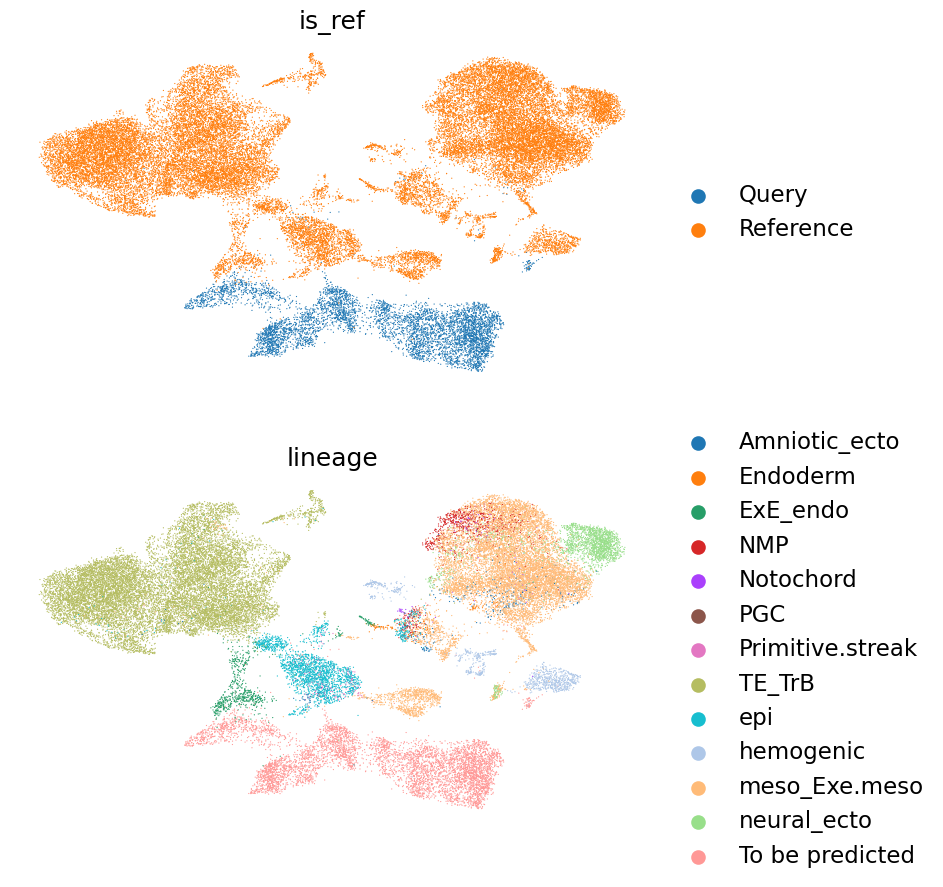

In [38]:
sc.pp.neighbors(adata_concat, use_rep="X_scGPT")
sc.tl.umap(adata_concat)
sc.pl.umap(adata_concat, color=["is_ref", cell_type_key], wspace=0.4, frameon=False, ncols=1)

In [39]:
ref_cell_embeddings = ref_embed_adata.obsm["X_scGPT"]
test_emebd = test_embed_adata.obsm["X_scGPT"]

k = 10  # number of neighbors

index = faiss.IndexFlatL2(ref_cell_embeddings.shape[1])
index.add(ref_cell_embeddings)

# Query dataset, k - number of closest elements (returns 2 numpy arrays)
distances, labels = index.search(test_emebd, k)

idx_list=[i for i in range(test_emebd.shape[0])]
preds = []
sim_list = distances
for k in idx_list:
    if faiss_imported:
        idx = labels[k]
    else:
        idx, sim = get_similar_vectors(test_emebd[k][np.newaxis, ...], ref_cell_embeddings, k)
    pred = ref_embed_adata.obs[cell_type_key][idx].value_counts()
    preds.append(pred.index[0])

In [40]:
preds

['meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'Amniotic_ecto',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'Amniotic_ecto',
 'meso_Exe.meso',
 'Amniotic_ecto',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'ExE_endo',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'Amniotic_ecto',
 'Amniotic_ecto',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'ExE_endo',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'Amniotic_ecto',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 'meso_Exe.meso',
 '

In [41]:
Weatherbee.obs["scgpt_final_lineage_pre"] = preds

In [42]:
Weatherbee.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,sample_type,scmap_nakamura,scmapCELL_Yang,scmap_ma,scmap_Tyser,scmapCELL_Mole,cell_assignment,course_cell_assignment,stage,species,embryo,platform,doublet,doublet_score,scgpt_final_anno_pre,scgpt_final_lineage_pre
AAACAGCCAATATACC-1_1,Weatherbee,7994.0,3257,4.953715,double_structure_day8,Post-paTE,unassigned,L-AM2,Amnion,Hypoblast,AM-3,AME,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,1.516193e-05,Rostral.mesoderm,meso_Exe.meso
AAACAGCCACTAAGCC-1_1,Weatherbee,8411.0,3593,4.541672,double_structure_day8,Post-paTE,unassigned,L-AM2,Amnion,Cytotrophoblasts,AM-3,AME,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,3.050282e-04,Somite,meso_Exe.meso
AAACATGCAGTATGTT-1_1,Weatherbee,7937.0,3497,3.187602,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,unassigned,Hypoblast,EXMC,EXMC,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,9.171038e-07,Rostral.mesoderm,meso_Exe.meso
AAACCAACAATAACCT-1_1,Weatherbee,10750.0,4132,2.483721,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,YS Mesoderm,Hypoblast,EXMC,EXMC,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,2.359281e-08,Exe.meso.progenitor,meso_Exe.meso
AAACCGAAGGCTAGAA-1_1,Weatherbee,10730.0,4098,3.122088,double_structure_day8,EXMC,extraembryonic mesenchyme,EXMC,YS Mesoderm,Hypoblast,EXMC,EXMC,D8,Homo sapiens,Embryo Model,10x-Genomics,0.0,2.735409e-09,Amniotic.mesoderm,meso_Exe.meso
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGAGTCATCCGTAA-1,Weatherbee,29746.0,6569,10.925839,double_structure_day4,PostL-EPI,unassigned,postL-EPI,Epiblast,Epiblast,L-EPI,L-EPI,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,3.586937e-04,Epiblast_3,epi
TTTGGTAAGTTACTTC-1,Weatherbee,44527.0,8383,8.978822,NA,NA,NA,NA,NA,NA,NA,NA,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,4.157939e+00,Neural.ectoderm.forebrain,neural_ecto
TTTGTCTAGCATGAAG-1,Weatherbee,9015.0,3987,3.982252,double_structure_day4,PostL-EPI,unassigned,L-AM1,Epiblast,unassigned,AM-1,AME,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,4.369414e-01,Epiblast_3,epi
TTTGTGAAGTTAACCA-1,Weatherbee,24582.0,6431,4.653812,double_structure_day4,EXMC,extraembryonic mesenchyme,L-Gast2,unassigned,unassigned,MESO-2,Meso,D4,Homo sapiens,Embryo Model,10x-Genomics,0.0,6.811725e-01,Exe.meso.progenitor,meso_Exe.meso


In [43]:
Weatherbee.obs.to_csv("/data2/lanxiang/embryo_benchmark/25.1.13_update/embryo_model_csv_updata/human_Weatherbee_scgpt.csv", index=True)

In [44]:
Weatherbee.write_h5ad("/data2/lanxiang/embryo_benchmark/25.1.13_update/embryo_model_csv_updata/human_Weatherbee_scgpt.h5ad")

In [45]:
import scgpt as scg
print(scg.__version__)


0.2.1
